# EU27 ESG — Exploratory Data Analysis
**Three core charts for the EDA section**

- Fig 1: Implementation Gap Trends (Panel data, 2005–2024)
- Fig 2: Gap Heatmap — 27 countries × 3 dimensions (2024)
- Fig 3: Sector Breakdown — Stacked bar (Sectors data)

> Place this notebook in the same folder as `EU27_ESG_Panel_2005_2024.csv` and `EU27_sectors.csv`

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
})
GREY = '#555555'

## 1. Load Data

In [2]:
panel   = pd.read_csv('EU27_ESG_Panel_2005_2024.csv')
sectors = pd.read_csv('EU27_sectors.csv')

eu27      = panel[panel['Country_Code'] == 'EU27'].sort_values('Year')
countries = panel[panel['Country_Code'] != 'EU27']
years     = sorted(countries['Year'].unique())

print('Panel shape:  ', panel.shape)
print('Sectors shape:', sectors.shape)
print('Years covered:', years[0], '–', years[-1])
panel.head(3)

Panel shape:   (560, 18)
Sectors shape: (27, 23)
Years covered: 2005 – 2024


,Country_Code,Year,Country_Name,FEC_Mtoe,FEC_FF55_Target_Mtoe,FEC_Impl_Gap_Mtoe,FEC_Impl_Gap_Pct,GHG_MtCO2eq,GHG_FF55_Target_Mt,GHG_Impl_Gap_Mt,GHG_Impl_Gap_Pct,RES_Share_Pct,RES_FF55_Target_Pct,RES_Impl_Gap_Pct,GDP_per_capita_PPP,Population,Composite_Gap_Score,Composite_Rank_Desc
0,AT,2005,Austria,26.29,21.6104,4.6796,17.8000,96.4267,36.0799,60.3468,62.5831,24.353,57.0,-32.647,34787.5,8227829,-0.6688,16.0
1,AT,2006,Austria,26.37,21.6104,4.7596,18.0494,93.9886,36.0799,57.9087,61.6125,26.276,57.0,-30.724,37399.1,8268641,-0.5812,15.0
2,AT,2007,Austria,25.95,21.6104,4.3396,16.7230,91.0048,36.0799,54.9250,60.3539,28.144,57.0,-28.856,39195.2,8295487,-0.4314,13.0


## 2. Fig 1 — Implementation Gap Trends

**Data**: `EU27_ESG_Panel_2005_2024.csv`  
**Variables used**:
- `GHG_Impl_Gap_Pct`, `RES_Impl_Gap_Pct`, `FEC_Impl_Gap_Pct` — gap to 2030 target (%)
- Filtered to `EU27` aggregate + 4 regional representative countries

**Design**: shaded band = 27-country min–max range, bold line = EU27, dashed = regional reps

In [3]:
# ── Configuration: change countries or colours here ──────────
# One representative country per geographic region
REPS = {
    'SE': ('N. Europe', '#2a7f5f'),
    'DE': ('W. Europe', '#1a5fa8'),
    'PL': ('E. Europe', '#c87800'),
    'ES': ('S. Europe', '#c0392b'),
}

# Three gap dimensions: (column, y-label, colour, subtitle)
DIMS = [
    ('GHG_Impl_Gap_Pct', 'GHG Gap (%)',  '#4e6d8c', 'GHG Emissions Gap'),
    ('RES_Impl_Gap_Pct', 'RES Gap (pp)', '#5a9e78', 'RES Share Gap'),
    ('FEC_Impl_Gap_Pct', 'FEC Gap (%)',  '#7b6db0', 'FEC Gap'),
]

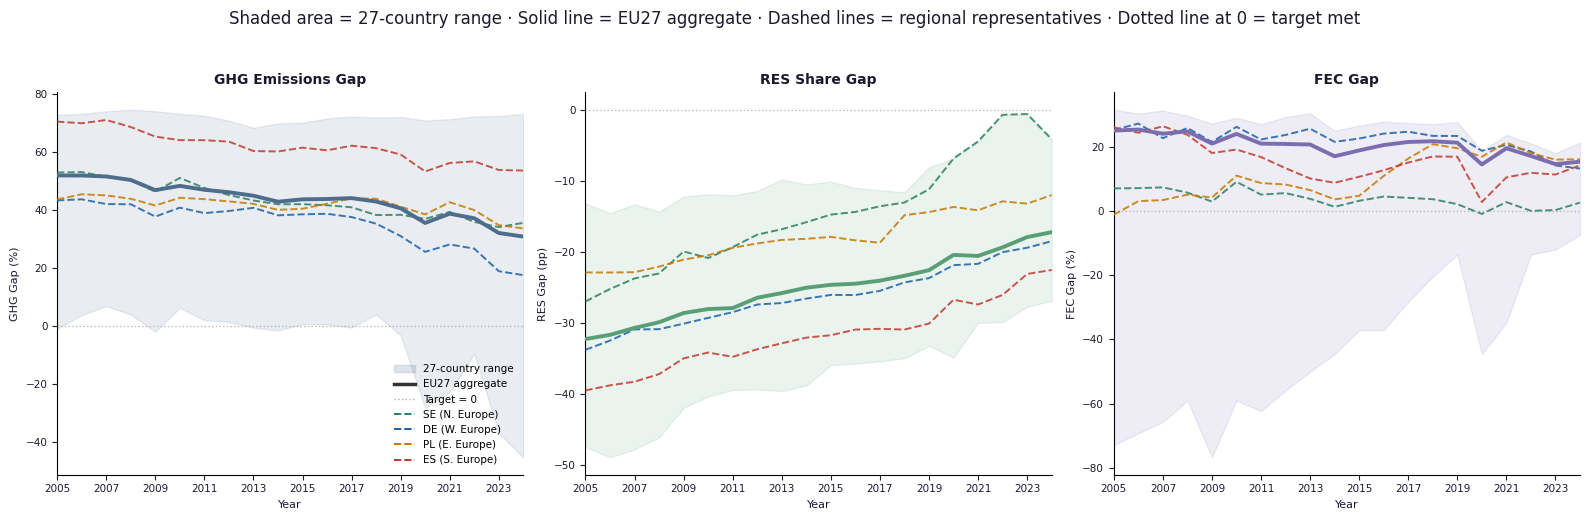

Saved: fig1_trend.png


In [8]:
fig1, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

fig1.suptitle(
    #'Fig 1  EU27 Implementation Gaps, 2005–2024\n'
    'Shaded area = 27-country range · Solid line = EU27 aggregate · '
    'Dashed lines = regional representatives · Dotted line at 0 = target met',
    fontsize=12, color='#1a1a2e', y=1.03
)

for ax, (col, ylabel, band_col, subtitle) in zip(axes, DIMS):
    grp = countries.groupby('Year')[col]

    # 27-country min–max band
    ax.fill_between(years, grp.min().values, grp.max().values,
                    color=band_col, alpha=0.12, zorder=1)

    # Zero reference line (target = 0)
    ax.axhline(0, color='#aaaaaa', lw=1, ls=':', alpha=0.8, zorder=2)

    # Regional representatives
    for cc, (region, lc) in REPS.items():
        d = countries[countries['Country_Code'] == cc].sort_values('Year')
        ax.plot(d['Year'], d[col], color=lc, lw=1.4, ls='--',
                alpha=0.85, zorder=3)

    # EU27 aggregate — thick solid line
    ax.plot(eu27['Year'], eu27[col], color=band_col, lw=2.8,
            zorder=4)

    ax.set_title(subtitle, fontsize=10, fontweight='bold',
                 color='#1a1a2e', pad=6)
    ax.set_xlabel('Year', fontsize=8, color='#1a1a2e')
    ax.set_ylabel(ylabel, fontsize=8, color='#1a1a2e')
    ax.tick_params(labelsize=7.5, colors='#1a1a2e')
    ax.set_xlim(2005, 2024)
    ax.set_xticks(range(2005, 2025, 2))
ax.set_xticklabels(range(2005, 2025, 2))

# Shared legend on first panel
legend_handles = [
    Patch(color='#4e6d8c', alpha=0.18, label='27-country range'),
    Line2D([0],[0], color='#333', lw=2.5,       label='EU27 aggregate'),
    Line2D([0],[0], color='#aaa', lw=1, ls=':', label='Target = 0'),
] + [
    Line2D([0],[0], color=lc, lw=1.4, ls='--', label=f'{cc} ({reg})')
    for cc, (reg, lc) in REPS.items()
]
axes[0].legend(handles=legend_handles, fontsize=7.5,
               frameon=False, loc='lower right')

fig1.tight_layout()
fig1.savefig('fig1_trend.png', dpi=150, bbox_inches='tight',
             facecolor='white')
plt.show()
print('Saved: fig1_trend.png')

## 3. Fig 2 — Gap Heatmap (2024 Cross-Section)

**Data**: `EU27_ESG_Panel_2005_2024.csv`, filtered to Year == 2024  
**Variables**: `GHG_Impl_Gap_Pct`, `RES_Impl_Gap_Pct`, `FEC_Impl_Gap_Pct`  
**Countries**: all 27, sorted alphabetically (no ranking implied)  

**Colour**: red = large gap (far from target), green = small gap or already met

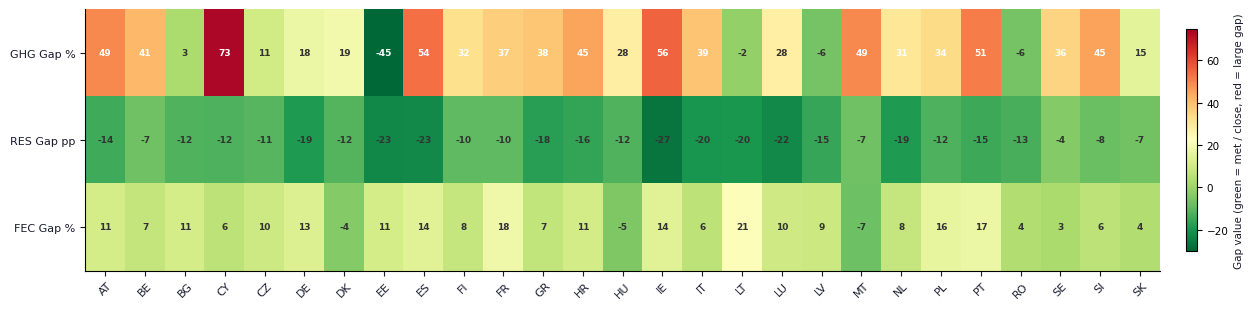

Saved: fig2_heatmap.png


In [13]:
lat = (countries[countries['Year'] == 2024]
       .sort_values('Country_Code')
       .reset_index(drop=True))

# Matrix shape: (3 dims) × (27 countries)
mat = lat[['GHG_Impl_Gap_Pct',
            'RES_Impl_Gap_Pct',
            'FEC_Impl_Gap_Pct']].values.T

fig2, ax = plt.subplots(figsize=(14, 3.2))

im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=-30, vmax=75)

# Axis labels
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['GHG Gap %', 'RES Gap pp', 'FEC Gap %'],
                   fontsize=9.5, color='#1a1a2e')
ax.set_xticks(range(27))
ax.set_xticklabels(lat['Country_Code'].tolist(),
                   fontsize=8, rotation=45, color='#1a1a2e')

# Annotate each cell with its value
for i in range(3):
    for j in range(27):
        v = mat[i, j]
        text_col = 'white' if abs(v) > 30 else '#333'
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=6.5, color=text_col, fontweight='bold')

cbar = fig2.colorbar(im, ax=ax, orientation='vertical',
                     pad=0.02, shrink=0.85, aspect=20)
cbar.ax.tick_params(labelsize=7.5)
cbar.set_label('Gap value (green = met / close, red = large gap)',
               fontsize=7.5, color='#1a1a2e')

# ax.set_title(
#     'Fig 2  Implementation Gap Heatmap — EU27, 2024  '
#     '(alphabetical order)',
#     fontsize=10, fontweight='bold', color='#1a1a2e', pad=10
# )
ax.tick_params(labelsize=8, colors='#1a1a2e')

fig2.tight_layout()
fig2.savefig('fig2_heatmap.png', dpi=150, bbox_inches='tight',
             facecolor='white')
plt.show()
print('Saved: fig2_heatmap.png')

## 4. Fig 3 — Sector Breakdown (Stacked Bar)

**Data**: `EU27_sectors.csv` (original scale, 2013–2024 mean)  
**Variables**: all sector columns under GHG / FEC / RES  
**Note**: raw values used (not standardised) so units are readable  

Three sub-charts side by side: GHG (MtCO₂eq) / FEC (ktoe) / RES (% share)

In [20]:
sectors_sorted = sectors.sort_values('Country_Code').reset_index(drop=True)
codes = sectors_sorted['Country_Code'].tolist()
x = np.arange(len(codes))

# ── Sector groups, labels, colours ─────────────────────────────
GHG_DIMS = ['GHG_Power_Industry','GHG_Transport','GHG_Industrial_Combustion',
            'GHG_Buildings','GHG_Agriculture','GHG_Fuel_Exploitation',
            'GHG_Processes','GHG_Waste']
GHG_LBLS = ['Power Industry','Transport','Industrial Comb.',
            'Buildings','Agriculture','Fuel Exploit.','Processes','Waste']
GHG_COLS = ['#c0392b','#e74c3c','#e67e22','#f39c12',
            '#d4a017','#c8b400','#a8a000','#8b8000']

FEC_DIMS = ['FEC_Industry','FEC_Transport','FEC_Households','FEC_Services']
FEC_LBLS = ['Industry','Transport','Households','Services']
FEC_COLS = ['#1a5fa8','#2980b9','#74b9e9','#abd9f5']

RES_DIMS = ['RES_Electricity','RES_HeatingCooling','RES_Transport']
RES_LBLS = ['Electricity','Heating & Cooling','Transport']
RES_COLS = ['#2a7f5f','#27ae60','#82e0aa']

# ── Helper function ─────────────────────────────────────────────
def stacked_bar(ax, dims, lbls, cols, title, ylabel, bar_width=0.6):
    bottom = np.zeros(len(codes))
    for d, l, c in zip(dims, lbls, cols):
        vals = sectors_sorted[d].values
        ax.bar(x, vals, bottom=bottom, width=bar_width,
               color=c, label=l, alpha=0.88)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(codes, rotation=45, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9, color='#1a1a2e')
    ax.set_title(title, fontsize=10, fontweight='bold',
                 color='#1a1a2e', pad=6)
    ax.tick_params(labelsize=8, colors='#1a1a2e')
    ax.legend(fontsize=8, frameon=False, loc='upper right',
              bbox_to_anchor=(1.0, 1.0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('white')

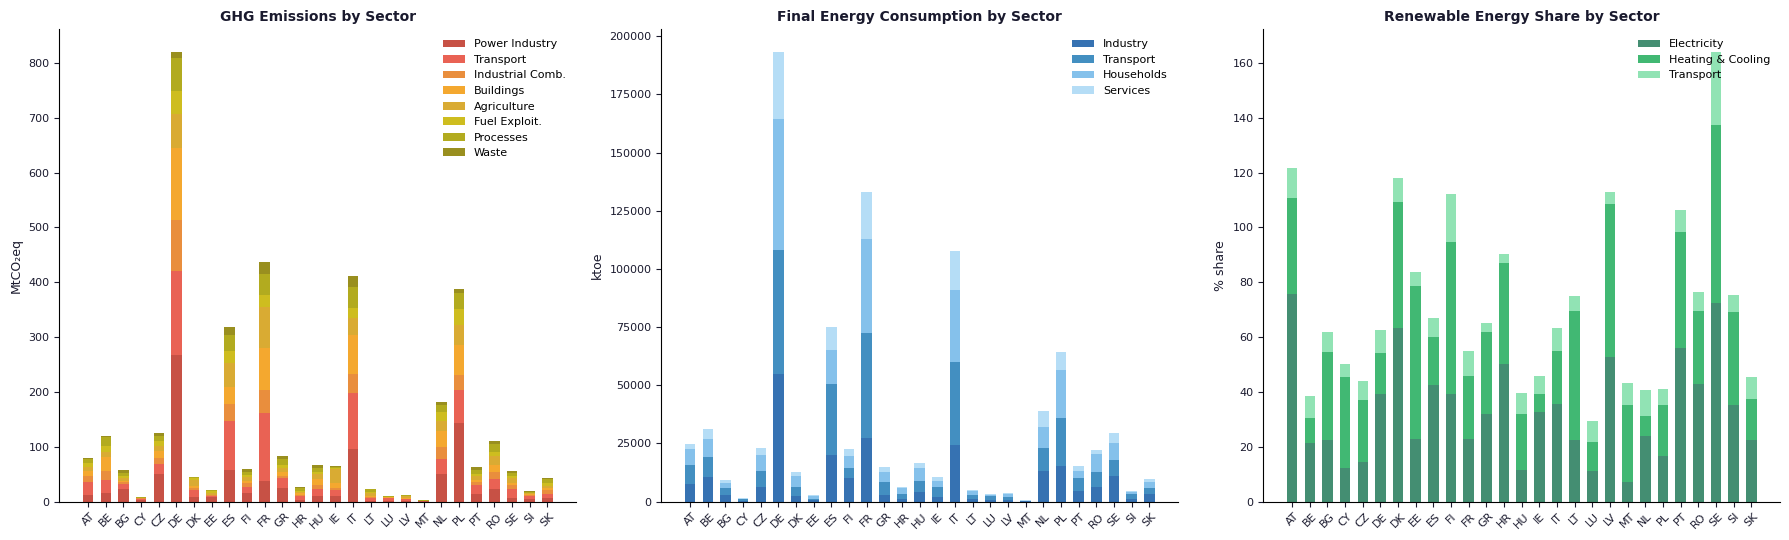

Saved: fig3_sector_stacked.png


In [22]:
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5.5))
fig3.patch.set_facecolor('white')
# fig3.suptitle(
#     'Fig 3  Sector Breakdown — EU27 Member States  '
#     '(2013–2024 period mean, original scale)',
#     fontsize=11, fontweight='bold', color='#1a1a2e', y=1.01
# )

stacked_bar(axes3[0], GHG_DIMS, GHG_LBLS, GHG_COLS,
            'GHG Emissions by Sector', 'MtCO₂eq')
stacked_bar(axes3[1], FEC_DIMS, FEC_LBLS, FEC_COLS,
            'Final Energy Consumption by Sector', 'ktoe')
stacked_bar(axes3[2], RES_DIMS, RES_LBLS, RES_COLS,
            'Renewable Energy Share by Sector', '% share')

fig3.tight_layout()
fig3.savefig('fig3_sector_stacked.png', dpi=150, bbox_inches='tight',
             facecolor='white')
plt.show()
print('Saved: fig3_sector_stacked.png')